# Two-dimensional Disk Distribution Functions

galpy includes several distribution functions (DFs) for razor-thin axisymmetric disks:
**dehnendf** (Dehnen 1999), **shudf** (Shu 1969), and **schwarzschilddf** (Schwarzschild).
These DFs are functions of energy and angular momentum, $f(E, L_z)$, and describe
stellar populations in a disk with a flat or power-law rotation curve.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## Types of 2D disk DFs

All three DFs assume an exponential surface-density profile and an exponential
velocity-dispersion profile by default. They differ in how they construct $f(E, L_z)$:

- **dehnendf**: Dehnen's 'new' DF (Dehnen 1999)
- **shudf**: Shu's DF (Shu 1969)
- **schwarzschilddf**: Schwarzschild DF

All operate in a potential with a power-law rotation curve $v_c \propto R^\beta$.

## Initializing a Dehnen DF

We initialize a `dehnendf` with a flat rotation curve (`beta=0.`). The default
`profileParams=(1/3, 1, 0.2)` set the disk scale length, velocity-dispersion
scale length, and velocity dispersion at $R_0$ (all in natural units).

In [2]:
from galpy.df import dehnendf

dfc = dehnendf(beta=0.0)

The `profileParams` tuple is `(xD, xS, Sro)` where:
- `xD = 1/3`: disk surface mass scale length (in units of $R_0$)
- `xS = 1.0`: velocity dispersion scale length
- `Sro = 0.2`: velocity dispersion at $R_0$ (in units of $v_c(R_0)$)

We can also use custom profile parameters:

In [3]:
dfc2 = dehnendf(beta=0.0, profileParams=(1.0 / 3.0, 1.0, 0.15))

## Evaluating the DF for an orbit

The DF can be evaluated for a given orbit (a point in phase space).
We create an `Orbit` object and pass it to the DF:

In [4]:
from galpy.orbit import Orbit

# An orbit at R=0.9, vR=0.05, vT=1.0
o = Orbit([0.9, 0.05, 1.0])
print("f(orbit) =", dfc(o))

f(orbit) = 0.3014411904461411


## DF moments: surface mass, velocity dispersions, and mean velocities

We can compute various moments of the DF by marginalizing over velocity.
These are useful for comparing the DF to observations.

In [5]:
# Surface mass density at R=1
print("Surface mass at R=1.0:", dfc.surfacemass(1.0))

# Radial velocity dispersion squared
print("sigma_R^2 at R=1.0:", dfc.sigma2(1.0))

# Mean tangential velocity
print("<v_T> at R=1.0:", dfc.meanvT(1.0))

# Mean radial velocity (should be ~0 for an axisymmetric DF)
print("<v_R> at R=1.0:", dfc.meanvR(1.0))

/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:626: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)



Surface mass at R=1.0: 0.050968080499022066


sigma_R^2 at R=1.0: 0.03733043742309621


<v_T> at R=1.0: 0.9171527697944728
<v_R> at R=1.0: 0.0


Let's plot the surface mass profile and compare it to the target exponential profile:

Text(0.5, 1.0, 'Surface mass density profile')

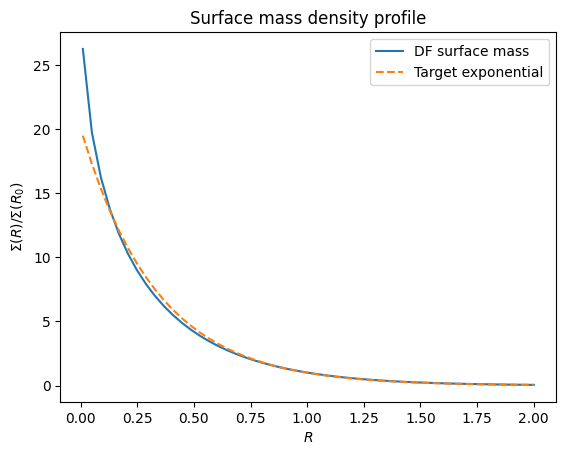

In [6]:
Rs = numpy.linspace(0.01, 2.0, 51)
smass = numpy.array([dfc.surfacemass(R) for R in Rs])
plt.plot(Rs, smass / smass[25], label="DF surface mass")
plt.plot(Rs, numpy.exp(-(Rs - 1.0) / (1.0 / 3.0)), "--", label="Target exponential")
plt.xlabel(r"$R$")
plt.ylabel(r"$\Sigma(R) / \Sigma(R_0)$")
plt.legend()
plt.title("Surface mass density profile")

## Asymmetric drift

The asymmetric drift is the difference between the circular velocity and
the mean tangential velocity: $v_c - \langle v_T \rangle$. The DF can
estimate this from an approximation to the Jeans equation:

Asymmetric drift at R=1.0: 0.09000000000000002


Text(0.5, 1.0, 'Asymmetric drift')

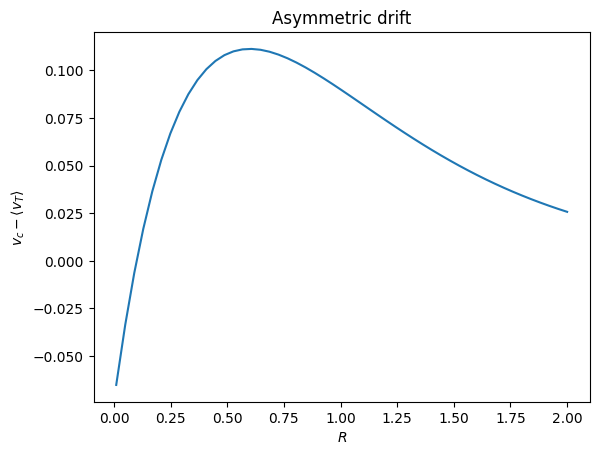

In [7]:
print("Asymmetric drift at R=1.0:", dfc.asymmetricdrift(1.0))

# Plot asymmetric drift as a function of R
ad = numpy.array([dfc.asymmetricdrift(R) for R in Rs])
plt.plot(Rs, ad)
plt.xlabel(r"$R$")
plt.ylabel(r"$v_c - \langle v_T \rangle$")
plt.title("Asymmetric drift")

## Sampling orbits from the DF

We can draw random samples from the DF. The `sample` method returns `Orbit` objects:

In [8]:
samples = dfc.sample(n=500, returnOrbit=True, nphi=1)
print("Number of sampled orbits:", len(samples))
print("First orbit R, vR, vT:", samples[0].R(), samples[0].vR(), samples[0].vT())

/home/bovy/Repos/galpy/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 7.491669e-05
  warnings.warn(

/home/bovy/Repos/galpy/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 3.477585e-05
  warnings.warn(



/home/bovy/Repos/galpy/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 3.290712e-06
  warnings.warn(

/home/bovy/Repos/galpy/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 1.493272e-06
  warnings.warn(



Number of sampled orbits: 500
First orbit R, vR, vT: 1.547568974735587 0.036280630365321725 0.951739874495652


## Plotting the velocity distribution

We can sample velocities at a specific radius and plot their distribution.
The `sampleVRVT` method samples $(v_R, v_T)$ at a given $R$:

/home/bovy/Repos/galpy/galpy/df/diskdf.py:1919: RuntimeWarning: overflow encountered in exp
  + numpy.exp(logOLLE - SRE2)



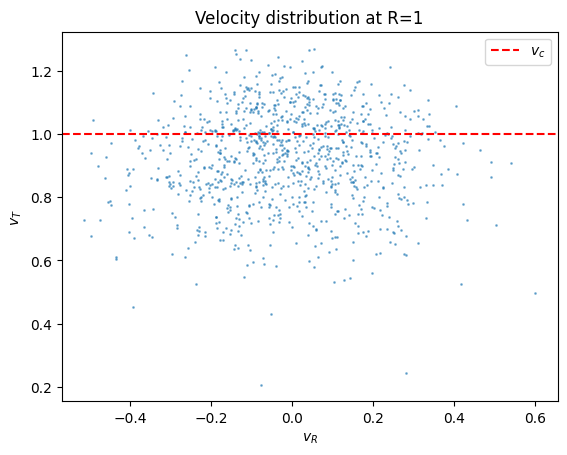

In [9]:
vrvt = dfc.sampleVRVT(1.0, n=1000)
plt.scatter(vrvt[:, 0], vrvt[:, 1], s=1, alpha=0.5)
plt.xlabel(r"$v_R$")
plt.ylabel(r"$v_T$")
plt.title("Velocity distribution at R=1")
plt.axhline(1.0, color="r", ls="--", label=r"$v_c$")
plt.legend()

The distribution is centered slightly below $v_c = 1$ due to the asymmetric drift,
and has a spread set by the velocity dispersion.

## Other 2D DFs

The `shudf` and `schwarzschilddf` classes have the same interface:

In [10]:
from galpy.df import shudf, schwarzschilddf

dfs = shudf(beta=0.0)
dfsw = schwarzschilddf(beta=0.0)

print("Shu DF surface mass at R=1:", dfs.surfacemass(1.0))
print("Schwarzschild DF surface mass at R=1:", dfsw.surfacemass(1.0))

Shu DF surface mass at R=1: 0.062193623796354555
Schwarzschild DF surface mass at R=1: 0.0689371283692479


## Corrected DFs

The input profiles are only approximately reproduced by the DF. We can correct
this by calculating a set of corrections (see Dehnen 1999). galpy supports
these corrections and comes with pre-calculated corrections bundled with the code:

sigma_R (corrected): 0.1999998506941359


meanvT (corrected): 0.9035516117477274


Text(0.5, 1.0, 'Corrected vs. uncorrected surface mass density')

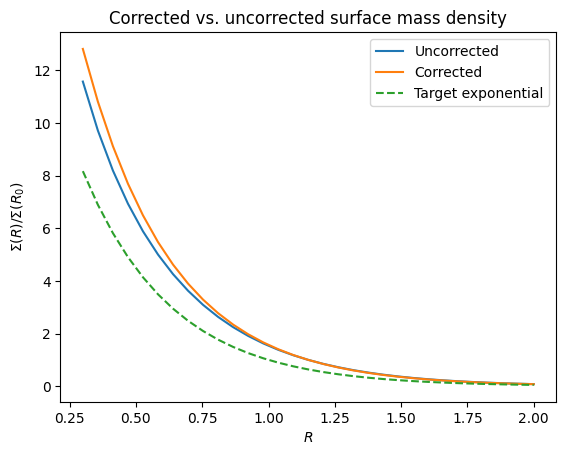

In [11]:
dfc_corr = dehnendf(beta=0.0, correct=True)

# The corrected DF reproduces the target velocity dispersion much better:
print("sigma_R (corrected):", numpy.sqrt(dfc_corr.sigmaR2(1.0)))
print("meanvT (corrected):", dfc_corr.meanvT(1.0))

# Compare surface mass profiles
Rs = numpy.linspace(0.3, 2.0, 31)
smass_uncorr = numpy.array([dfc.surfacemass(R) for R in Rs])
smass_corr = numpy.array([dfc_corr.surfacemass(R) for R in Rs])
plt.plot(Rs, smass_uncorr / smass_uncorr[15], label="Uncorrected")
plt.plot(Rs, smass_corr / smass_corr[15], label="Corrected")
plt.plot(Rs, numpy.exp(-(Rs - 1.0) / (1.0 / 3.0)), "--", label="Target exponential")
plt.xlabel(r"$R$")
plt.ylabel(r"$\Sigma(R) / \Sigma(R_0)$")
plt.legend()
plt.title("Corrected vs. uncorrected surface mass density")

## Oort constants

galpy can calculate the Oort constants (A, B, C, K) for 2D disk DFs by direct
integration over the DF and its derivatives:

In [12]:
print("Oort A:", dfc.oortA(1.0))
print("Oort B:", dfc.oortB(1.0))
print("Oort C:", dfc.oortC(1.0))  # zero for axisymmetric DFs
print("Oort K:", dfc.oortK(1.0))  # zero for axisymmetric DFs
# In the epicycle approximation for a flat rotation curve, A = -B = 0.5
print("A + B (should be ~0 for cold DF):", dfc.oortA(1.0) + dfc.oortB(1.0))

# For a cold DF, the epicycle approximation is better:
dfccold = dehnendf(beta=0.0, profileParams=(1.0 / 3.0, 1.0, 0.02))
print("Cold DF: A =", dfccold.oortA(1.0), ", B =", dfccold.oortB(1.0))

Oort A: 0.4319078088921877


Oort B: -0.4852449609022851


Oort C: 0.0


Oort K: 0.0


A + B (should be ~0 for cold DF): -0.053337152010097366


Cold DF: A = 0.4991755666614268 , B = -0.4999282474249216


## Line-of-sight sampling

galpy supports sampling along a given line of sight in the disk, useful for
interpreting surveys with a finite number of pointings:

Text(0.5, 1.0, 'Distance distribution along l=30 deg')

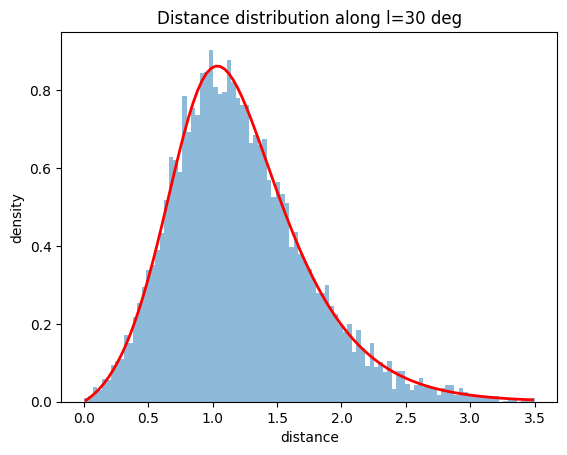

In [13]:
# Sample distances along a line of sight at l=30 degrees
ds = dfc.sampledSurfacemassLOS(30.0 / 180.0 * numpy.pi, n=10000)
hists, bins, edges = plt.hist(ds, range=[0.0, 3.5], density=True, bins=101, alpha=0.5)
# Compare to the predicted distribution
xs = numpy.array([(bins[ii + 1] + bins[ii]) / 2.0 for ii in range(len(bins) - 1)])
fd = numpy.array([dfc.surfacemassLOS(d, 30.0) for d in xs])
plt.plot(xs, fd / numpy.sum(fd) / (xs[1] - xs[0]), "r-", lw=2)
plt.xlabel("distance")
plt.ylabel("density")
plt.title("Distance distribution along l=30 deg")

## Non-axisymmetric, time-dependent DFs: evolveddiskdf

galpy supports evaluation of non-axisymmetric, time-dependent 2D DFs.
These are constructed by assuming an initial axisymmetric steady state
that is then acted upon by a non-axisymmetric perturbation. The DF at any
time is evaluated by integrating orbits backwards to the initial time
(using Liouville's theorem). This is implemented as `galpy.df.evolveddiskdf`.

In [14]:
from galpy.potential import LogarithmicHaloPotential, EllipticalDiskPotential
from galpy.df import evolveddiskdf

# Set up an elliptical perturbation to a logarithmic potential
lp = LogarithmicHaloPotential(normalize=1.0)
ep = EllipticalDiskPotential(twophio=0.05, phib=0.0, p=0.0, tform=-150.0, tsteady=125.0)

# Initial steady-state DF (warm disk)
idfwarm = dehnendf(beta=0.0, profileParams=(1.0 / 3.0, 1.0, 0.15))

# Set up the evolved DF
edfwarm = evolveddiskdf(idfwarm, [lp, ep], to=-150.0)

# Mean radial velocity at R=0.9, phi=22.5 deg
mvrwarm, gridwarm = edfwarm.meanvR(
    0.9, phi=22.5, deg=True, t=0.0, grid=True, returnGrid=True, gridpoints=51
)
print("Mean v_R (warm disk):", mvrwarm)

Mean v_R (warm disk): -0.029476364282585484


## The Hercules stream

The `evolveddiskdf` machinery can be used to model the Hercules stream in the
Solar neighborhood as the result of the Galactic bar. By backward-integrating
orbits in a potential that includes a bar (e.g., `DehnenBarPotential`),
one can evaluate what velocity distribution we should see today. The bimodality
in the $(v_R, v_T)$ plane created by the bar's outer Lindblad resonance is known
as the Hercules stream. See the galpy documentation for a full worked example using
`evolveddiskdf` with `DehnenBarPotential`.